# Dynamic Support Breakdown – Trailing Stop: Backtest
Replicates the Pine Script strategy logic on **BTC-USD 1H** data (last 6 months).

### Strategy rules
| Parameter | Value |
|---|---|
| Fast EMA | 9 |
| Slow EMA | 21 |
| ATR period | 14 |
| Support lookback | 20 bars |
| Entry | Bearish EMA cross **AND** close < dynamic support |
| Direction | Short only |
| Initial SL | entry + ATR × 1.5 |
| Take profit | entry − ATR × 1.5 × 2.0 |
| Trailing SL | min(current SL, close + ATR × 1.0) each bar |
| Position size | 10 % of equity |

In [1]:
# ── 0. Install / import ──────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["yfinance", "pandas", "numpy", "matplotlib"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

print("Libraries ready")

Libraries ready


In [2]:
# ── 1. Download data ─────────────────────────────────────────────────────────
df = yf.download("BTC-USD", period="6mo", interval="1h", auto_adjust=True, progress=False)

# Flatten multi-index columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.dropna(inplace=True)
print(f"Rows: {len(df)}  |  {df.index[0]}  →  {df.index[-1]}")
df.tail(3)

Rows: 4314  |  2025-09-02 20:00:00+00:00  →  2026-03-02 20:00:00+00:00


Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-03-02 18:00:00+00:00,69182.984375,69227.859375,68829.765625,68984.875000,1440014336
2026-03-02 19:00:00+00:00,68891.804688,69030.914062,68620.500000,68949.632812,1445224448
2026-03-02 20:00:00+00:00,68963.578125,68963.578125,68963.578125,68963.578125,0


In [3]:
# ── 2. Indicators ─────────────────────────────────────────────────────────────
EMA_FAST   = 9
EMA_SLOW   = 21
ATR_PERIOD = 14
LOOKBACK   = 20
ATR_SL     = 1.5
RR_RATIO   = 2.0
TRAIL_MULT = 1.0

df["EMA9"]  = df["Close"].ewm(span=EMA_FAST,  adjust=False).mean()
df["EMA21"] = df["Close"].ewm(span=EMA_SLOW,  adjust=False).mean()

# ATR (Wilder / RMA)
high_low  = df["High"] - df["Low"]
high_pc   = (df["High"] - df["Close"].shift(1)).abs()
low_pc    = (df["Low"]  - df["Close"].shift(1)).abs()
tr        = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df["ATR"]  = tr.ewm(alpha=1/ATR_PERIOD, adjust=False).mean()   # Wilder smoothing

# Dynamic support = lowest Low of last LOOKBACK bars, shifted 1 (same as Pine [1])
df["DynSupport"] = df["Low"].rolling(LOOKBACK).min().shift(1)

# Bearish cross: EMA9 crosses UNDER EMA21
df["CrossUnder"] = (df["EMA9"] < df["EMA21"]) & (df["EMA9"].shift(1) >= df["EMA21"].shift(1))

df.dropna(inplace=True)
print("Indicators calculated. Sample:")
df[["Close","EMA9","EMA21","ATR","DynSupport","CrossUnder"]].tail(5)

Indicators calculated. Sample:


Price,Close,EMA9,EMA21,ATR,DynSupport,CrossUnder
Datetime,,,,,,
2026-03-02 16:00:00+00:00,69511.750000,67365.168440,66801.430413,808.302307,65114.421875,False
2026-03-02 17:00:00+00:00,69117.023438,67715.539439,67011.938870,797.302477,65123.964844,False
2026-03-02 18:00:00+00:00,68984.875000,67969.406551,67191.296700,768.787568,65123.964844,False
2026-03-02 19:00:00+00:00,68949.632812,68165.451804,67351.145437,743.189461,65230.656250,False
2026-03-02 20:00:00+00:00,68963.578125,68325.077068,67497.730227,691.100593,65309.109375,False


In [4]:
# ── 3. Backtest simulation (bar-by-bar loop) ──────────────────────────────────
INITIAL_CAPITAL = 10_000.0
QTY_PCT         = 0.10          # 10 % of equity per trade

equity       = INITIAL_CAPITAL
position     = None             # dict when in a trade
trades       = []
equity_curve = []

for ts, row in df.iterrows():
    close = float(row["Close"])
    atr   = float(row["ATR"])

    # ── Manage open position ──────────────────────────────────────────────
    if position is not None:
        # Update trailing stop (move DOWN only → math.min)
        potential_trail = close + atr * TRAIL_MULT
        position["sl"] = min(position["sl"], potential_trail)

        hit_sl = close >= position["sl"]
        hit_tp = close <= position["tp"]

        if hit_tp or hit_sl:
            exit_price = position["sl"] if hit_sl else position["tp"]
            pnl_pct    = (position["entry"] - exit_price) / position["entry"]   # short PnL
            dollar_pnl = pnl_pct * position["risk_capital"]
            equity    += dollar_pnl
            trades.append({
                "entry_time":  position["entry_time"],
                "exit_time":   ts,
                "entry":       position["entry"],
                "exit":        exit_price,
                "sl_initial":  position["sl_initial"],
                "tp":          position["tp"],
                "result":      "TP" if hit_tp else "SL",
                "pnl_pct":     round(pnl_pct * 100, 3),
                "dollar_pnl":  round(dollar_pnl, 2),
                "equity":      round(equity, 2),
            })
            position = None

    # ── Check for new entry ───────────────────────────────────────────────
    if position is None:
        bearish_cross   = bool(row["CrossUnder"])
        below_support   = close < float(row["DynSupport"])
        if bearish_cross and below_support:
            risk_amount    = atr * ATR_SL
            sl_price       = close + risk_amount
            tp_price       = close - risk_amount * RR_RATIO
            risk_capital   = equity * QTY_PCT
            position = {
                "entry":        close,
                "entry_time":   ts,
                "sl":           sl_price,
                "sl_initial":   sl_price,
                "tp":           tp_price,
                "risk_capital": risk_capital,
            }

    equity_curve.append({"time": ts, "equity": equity})

print(f"Simulation complete.  Trades found: {len(trades)}")

Simulation complete.  Trades found: 27


In [5]:
# ── 4. Summary statistics ─────────────────────────────────────────────────────
tdf = pd.DataFrame(trades)

if tdf.empty:
    print("No trades executed in this period.")
else:
    wins      = tdf[tdf["result"] == "TP"]
    losses    = tdf[tdf["result"] == "SL"]
    win_rate  = len(wins) / len(tdf) * 100
    avg_win   = wins["dollar_pnl"].mean()   if not wins.empty   else 0
    avg_loss  = losses["dollar_pnl"].mean() if not losses.empty else 0
    total_pnl = tdf["dollar_pnl"].sum()
    final_eq  = tdf["equity"].iloc[-1]
    best      = tdf["dollar_pnl"].max()
    worst     = tdf["dollar_pnl"].min()

    # Max drawdown on equity curve
    eq_series = pd.Series([t["equity"] for t in equity_curve])
    roll_max  = eq_series.cummax()
    drawdown  = (eq_series - roll_max) / roll_max * 100
    max_dd    = drawdown.min()

    print("=" * 46)
    print(f"  BACKTEST RESULTS  (BTC-USD 1H, 6 months)")
    print("=" * 46)
    print(f"  Initial capital   : ${INITIAL_CAPITAL:>10,.2f}")
    print(f"  Final equity      : ${final_eq:>10,.2f}")
    print(f"  Net P&L           : ${total_pnl:>+10,.2f}")
    print(f"  Return            : {(final_eq/INITIAL_CAPITAL - 1)*100:>+9.2f} %")
    print(f"  Max drawdown      : {max_dd:>9.2f} %")
    print("-" * 46)
    print(f"  Total trades      : {len(tdf):>5}")
    print(f"  Wins (TP)         : {len(wins):>5}")
    print(f"  Losses (SL/Trail) : {len(losses):>5}")
    print(f"  Win rate          : {win_rate:>8.1f} %")
    print(f"  Avg win  $        : ${avg_win:>+9,.2f}")
    print(f"  Avg loss $        : ${avg_loss:>+9,.2f}")
    print(f"  Best trade $      : ${best:>+9,.2f}")
    print(f"  Worst trade $     : ${worst:>+9,.2f}")
    print("=" * 46)

tdf

  BACKTEST RESULTS  (BTC-USD 1H, 6 months)
  Initial capital   : $ 10,000.00
  Final equity      : $ 10,021.13
  Net P&L           : $    +21.12
  Return            :     +0.21 %
  Max drawdown      :     -0.40 %
----------------------------------------------
  Total trades      :    27
  Wins (TP)         :     6
  Losses (SL/Trail) :    21
  Win rate          :     22.2 %
  Avg win  $        : $   +16.17
  Avg loss $        : $    -3.62
  Best trade $      : $   +25.17
  Worst trade $     : $   -12.76


,entry_time,exit_time,entry,exit,sl_initial,tp,result,pnl_pct,dollar_pnl,equity
0,2025-09-09 15:00:00+00:00,2025-09-09 20:00:00+00:00,110944.890625,111422.809572,111627.933972,109578.803932,SL,-0.431,-4.31,9995.69
1,2025-09-13 16:00:00+00:00,2025-09-13 20:00:00+00:00,115382.093750,115831.842809,115831.842809,114482.595631,SL,-0.390,-3.90,9991.80
2,2025-09-15 08:00:00+00:00,2025-09-15 18:00:00+00:00,114832.109375,115111.069990,115479.419093,113537.489940,SL,-0.243,-2.43,9989.37
3,2025-09-17 14:00:00+00:00,2025-09-17 17:00:00+00:00,115657.437500,116042.355915,116204.250753,114563.810993,SL,-0.333,-3.32,9986.04
4,2025-10-04 18:00:00+00:00,2025-10-04 21:00:00+00:00,121626.851562,122182.273806,122182.273806,120516.007075,SL,-0.457,-4.56,9981.48
5,2025-10-14 02:00:00+00:00,2025-10-14 07:00:00+00:00,113828.171875,111893.086897,114795.714364,111893.086897,TP,1.700,16.97,9998.45
6,2025-10-21 02:00:00+00:00,2025-10-21 05:00:00+00:00,109525.609375,107807.882394,110384.472865,107807.882394,TP,1.568,15.68,10014.13
7,2025-10-27 22:00:00+00:00,2025-10-28 01:00:00+00:00,114117.039062,114403.731556,114821.759010,112707.599168,SL,-0.251,-2.52,10011.62
8,2025-10-28 19:00:00+00:00,2025-10-29 06:00:00+00:00,113635.195312,113134.112675,114578.190065,111749.205807,SL,0.441,4.41,10016.03
9,2025-11-12 15:00:00+00:00,2025-11-13 01:00:00+00:00,102100.945312,101953.599257,103132.012296,100038.811345,SL,0.144,1.45,10017.48


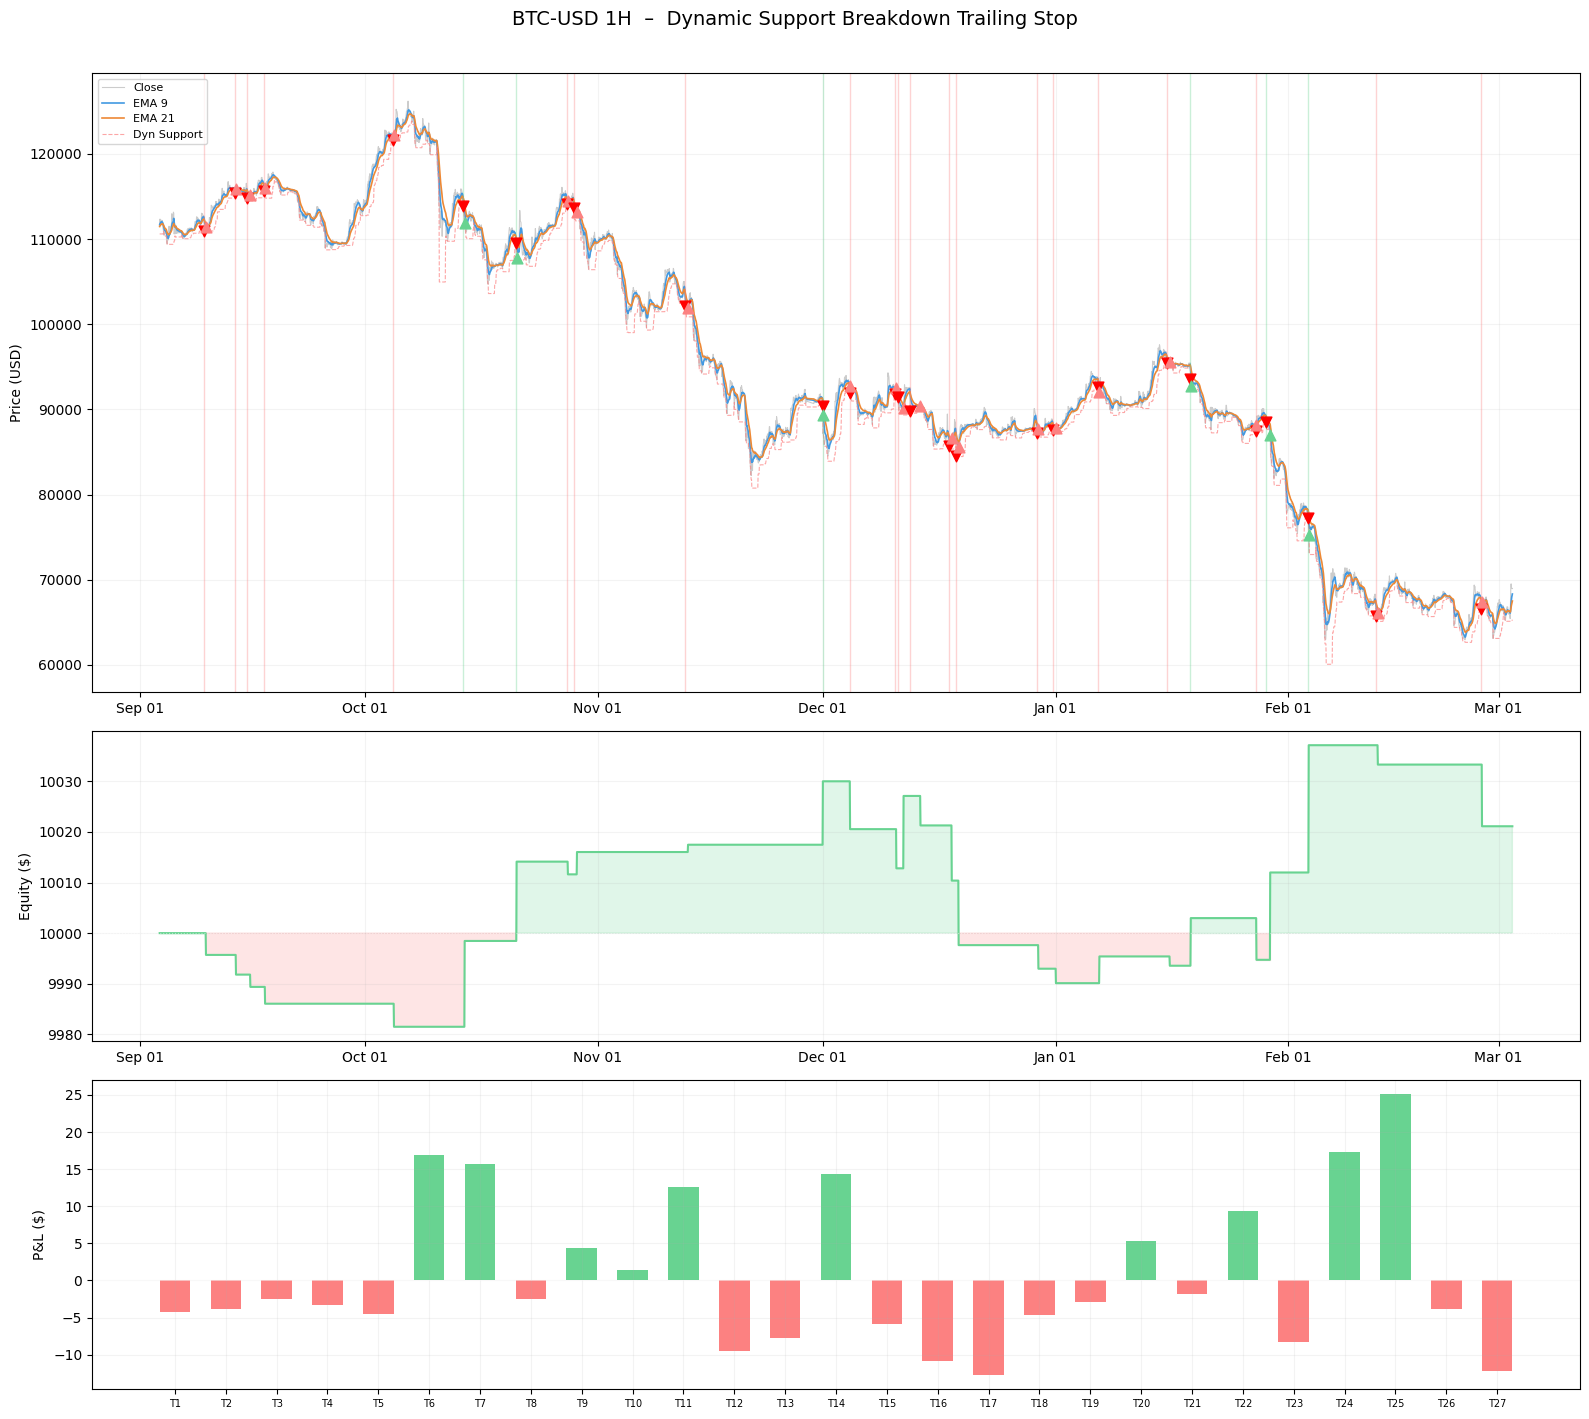

Chart saved → backtest_results.png


In [6]:
# ── 5. Charts ─────────────────────────────────────────────────────────────────
ec_df = pd.DataFrame(equity_curve).set_index("time")

fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                          gridspec_kw={"height_ratios": [3, 1.5, 1.5]})
fig.suptitle("BTC-USD 1H  –  Dynamic Support Breakdown Trailing Stop", fontsize=14, y=1.01)

# ── Panel 1: Price + EMAs + signals ──────────────────────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df["Close"],   color="#cccccc", lw=0.8, label="Close")
ax1.plot(df.index, df["EMA9"],    color="#4299e1", lw=1.2, label="EMA 9")
ax1.plot(df.index, df["EMA21"],   color="#ed8936", lw=1.2, label="EMA 21")
ax1.plot(df.index, df["DynSupport"], color="#fc8181", lw=0.8, ls="--", alpha=0.7, label="Dyn Support")

if not tdf.empty:
    for _, t in tdf.iterrows():
        color = "#68d391" if t["result"] == "TP" else "#fc8181"
        ax1.axvline(t["entry_time"], color=color, alpha=0.35, lw=1)
        ax1.scatter(t["entry_time"], t["entry"], marker="v", color="red", s=60, zorder=5)
        ax1.scatter(t["exit_time"],  t["exit"],  marker="^", color=color,  s=60, zorder=5)

ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 2: Equity curve ─────────────────────────────────────────────────────
ax2 = axes[1]
color_line = "#68d391" if ec_df["equity"].iloc[-1] >= INITIAL_CAPITAL else "#fc8181"
ax2.plot(ec_df.index, ec_df["equity"], color=color_line, lw=1.5)
ax2.axhline(INITIAL_CAPITAL, color="white", ls=":", lw=0.8, alpha=0.5)
ax2.fill_between(ec_df.index, INITIAL_CAPITAL, ec_df["equity"],
                 where=ec_df["equity"] >= INITIAL_CAPITAL, alpha=0.2, color="#68d391")
ax2.fill_between(ec_df.index, INITIAL_CAPITAL, ec_df["equity"],
                 where=ec_df["equity"] < INITIAL_CAPITAL,  alpha=0.2, color="#fc8181")
ax2.set_ylabel("Equity ($)")
ax2.grid(alpha=0.15)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 3: Per-trade P&L bars ───────────────────────────────────────────────
ax3 = axes[2]
if not tdf.empty:
    colors_bar = ["#68d391" if v >= 0 else "#fc8181" for v in tdf["dollar_pnl"]]
    ax3.bar(range(len(tdf)), tdf["dollar_pnl"], color=colors_bar, width=0.6)
    ax3.axhline(0, color="white", lw=0.7, alpha=0.5)
    ax3.set_xticks(range(len(tdf)))
    ax3.set_xticklabels([f"T{i+1}" for i in range(len(tdf))], fontsize=7)
    ax3.set_ylabel("P&L ($)")
ax3.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("backtest_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → backtest_results.png")